# Part 3 — Noise Sweep & Threshold Analysis
## How do the decoders hold up as physical error rate increases?

This notebook:
1. Loads the trained Part 1 and Part 2 decoders
2. Generates fresh data at each noise level (from the sweep files in `data/sweep/`)
3. Evaluates logical error rate vs physical error rate p
4. Compares Part 1 vs Part 2 vs Trivial decoder

**The key question:** Does Part 2 (raw measurements) still beat Part 1 (detection events)
at higher noise? Or does the harder input representation hurt it more?

### Requires
- `data/sweep/` directory from `01_data_generation.ipynb`
- `models/decoder_part1.pt` and `models/decoder_part2.pt` from `02_decoder_training.ipynb`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import glob, os, warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


---
## 1. Reload Model Architecture & Checkpoints

In [2]:
class SurfaceCodeDecoder(nn.Module):
    def __init__(self, input_dim: int, hidden=[256, 128, 64], dropout=0.3):
        super().__init__()
        layers = []
        in_dim = input_dim
        for i, h in enumerate(hidden):
            layers += [
                nn.Linear(in_dim, h), nn.BatchNorm1d(h), nn.ReLU(),
                nn.Dropout(dropout if i < len(hidden) - 1 else 0.0),
            ]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def load_model(path):
    ckpt  = torch.load(path, map_location='cpu', weights_only=False)
    model = SurfaceCodeDecoder(ckpt['input_dim'], ckpt['hidden'])
    model.load_state_dict(ckpt['model_state'])
    model.to(DEVICE).eval()
    return model, ckpt


@torch.no_grad()
def predict(model, X, batch_size=2048):
    ds     = TensorDataset(torch.tensor(X, dtype=torch.float32))
    loader = DataLoader(ds, batch_size=batch_size)
    preds  = []
    for (Xb,) in loader:
        logits = model(Xb.to(DEVICE))
        preds.append((torch.sigmoid(logits) > 0.5).cpu().numpy())
    return np.concatenate(preds)


model_p1, ckpt1 = load_model("models/decoder_part1.pt")
model_p2, ckpt2 = load_model("models/decoder_part2.pt")

print("Models loaded")
print(f"  Part 1: input_dim={ckpt1['input_dim']}  train_test_ler={ckpt1['test_ler']:.5f}")
print(f"  Part 2: input_dim={ckpt2['input_dim']}  train_test_ler={ckpt2['test_ler']:.5f}")

Models loaded
  Part 1: input_dim=72  train_test_ler=0.01447
  Part 2: input_dim=72  train_test_ler=0.03660


---
## 2. Evaluate Across Noise Levels

In [3]:
sweep_dir = "data/sweep"

# Find all noise levels from saved files
obs_files = sorted(glob.glob(f"{sweep_dir}/obs_p*.npy"))
tags       = [os.path.basename(f).replace('obs_p','').replace('.npy','') for f in obs_files]
noise_levels = [int(t) / 10000 for t in tags]

print(f"Found {len(noise_levels)} noise levels: {noise_levels}")
print()

results = []   # (p, trivial_ler, ler_p1, ler_p2)

print(f"{'p':>8}  {'Trivial':>10}  {'Part 1 (det)':>14}  {'Part 2 (raw)':>14}  {'P1 better?':>12}")
print("-" * 65)

for p, tag in zip(noise_levels, tags):
    det = np.load(f"{sweep_dir}/det_p{tag}.npy").astype(np.float32)
    raw = np.load(f"{sweep_dir}/raw_p{tag}.npy").astype(np.float32)
    obs = np.load(f"{sweep_dir}/obs_p{tag}.npy").astype(np.float32).squeeze()

    trivial = obs.mean()

    pred1 = predict(model_p1, det)
    pred2 = predict(model_p2, raw)

    ler1 = (pred1 != obs).mean()
    ler2 = (pred2 != obs).mean()

    results.append((p, trivial, ler1, ler2))

    p1_better = "✓ Part 1" if ler1 < ler2 else "✓ Part 2" if ler2 < ler1 else "Tie"
    print(f"  p={p:.4f}  trivial={100*trivial:6.3f}%  "
          f"Part1={100*ler1:6.3f}%  Part2={100*ler2:6.3f}%  {p1_better}")

Found 6 noise levels: [0.0005, 0.001, 0.002, 0.005, 0.01, 0.02]

       p     Trivial    Part 1 (det)    Part 2 (raw)    P1 better?
-----------------------------------------------------------------
  p=0.0005  trivial= 2.862%  Part1= 0.592%  Part2= 1.802%  ✓ Part 1
  p=0.0010  trivial= 5.272%  Part1= 1.420%  Part2= 3.696%  ✓ Part 1
  p=0.0020  trivial=10.162%  Part1= 3.824%  Part2= 7.572%  ✓ Part 1
  p=0.0050  trivial=22.114%  Part1=14.132%  Part2=20.210%  ✓ Part 1
  p=0.0100  trivial=34.362%  Part1=30.946%  Part2=36.138%  ✓ Part 1
  p=0.0200  trivial=45.250%  Part1=46.234%  Part2=48.056%  ✓ Part 1


---
## 3. Visualise

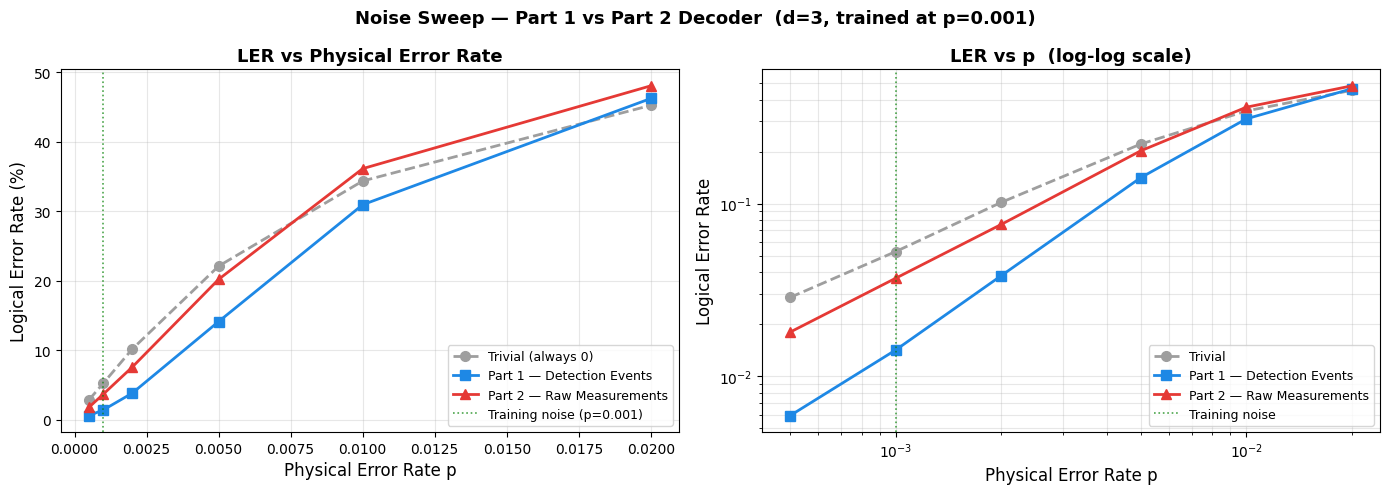

Saved → noise_sweep.png


In [4]:
ps       = [r[0] for r in results]
trivials = [r[1] for r in results]
ler1s    = [r[2] for r in results]
ler2s    = [r[3] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: LER vs p (linear) ───────────────────────────────────────────────────
ax = axes[0]
ax.plot(ps, [100*t for t in trivials], 'o--', color='#9E9E9E', lw=2, ms=7, label='Trivial (always 0)')
ax.plot(ps, [100*l for l in ler1s],    's-',  color='#1E88E5', lw=2, ms=7, label='Part 1 — Detection Events')
ax.plot(ps, [100*l for l in ler2s],    '^-',  color='#E53935', lw=2, ms=7, label='Part 2 — Raw Measurements')
ax.axvline(x=0.001, color='green', lw=1.2, ls=':', alpha=0.7, label='Training noise (p=0.001)')
ax.set_xlabel('Physical Error Rate p', fontsize=12)
ax.set_ylabel('Logical Error Rate (%)', fontsize=12)
ax.set_title('LER vs Physical Error Rate', fontweight='bold', fontsize=13)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── Right: LER vs p (log-log) — easier to see scaling ─────────────────────────
ax = axes[1]
ax.loglog(ps, [max(l,1e-6) for l in trivials], 'o--', color='#9E9E9E', lw=2, ms=7, label='Trivial')
ax.loglog(ps, [max(l,1e-6) for l in ler1s],    's-',  color='#1E88E5', lw=2, ms=7, label='Part 1 — Detection Events')
ax.loglog(ps, [max(l,1e-6) for l in ler2s],    '^-',  color='#E53935', lw=2, ms=7, label='Part 2 — Raw Measurements')
ax.axvline(x=0.001, color='green', lw=1.2, ls=':', alpha=0.7, label='Training noise')
ax.set_xlabel('Physical Error Rate p', fontsize=12)
ax.set_ylabel('Logical Error Rate', fontsize=12)
ax.set_title('LER vs p  (log-log scale)', fontweight='bold', fontsize=13)
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which='both')
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

fig.suptitle('Noise Sweep — Part 1 vs Part 2 Decoder  (d=3, trained at p=0.001)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('noise_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → noise_sweep.png")

---
## 4. Improvement Ratio vs Noise

How many times better than trivial is each decoder, at each noise level?
When this ratio drops below 1×, the decoder is worse than doing nothing.

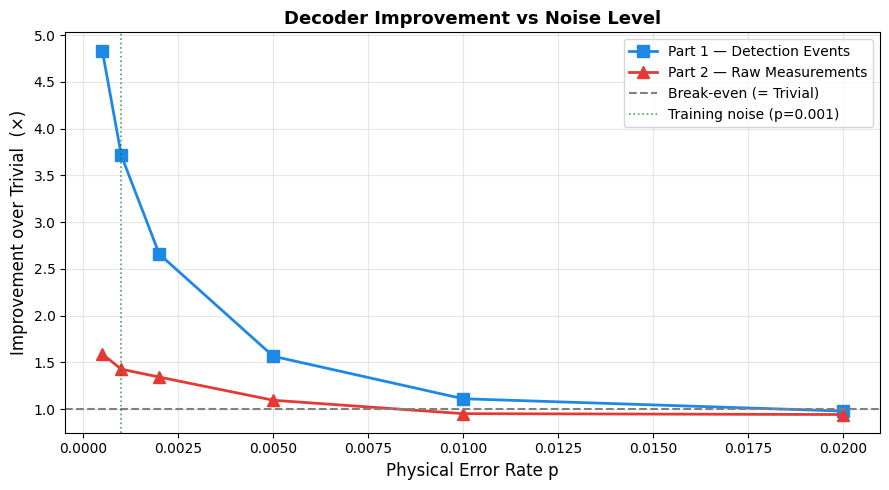


Summary table
       p    Part 1 ratio    Part 2 ratio
----------------------------------------
  p=0.0005            4.8x            1.6x
  p=0.0010            3.7x            1.4x
  p=0.0020            2.7x            1.3x
  p=0.0050            1.6x            1.1x
  p=0.0100            1.1x            1.0x
  p=0.0200            1.0x            0.9x


In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ratio1 = [t/l if l > 0 else float('inf') for t, l in zip(trivials, ler1s)]
ratio2 = [t/l if l > 0 else float('inf') for t, l in zip(trivials, ler2s)]

ax.plot(ps, ratio1, 's-', color='#1E88E5', lw=2, ms=8, label='Part 1 — Detection Events')
ax.plot(ps, ratio2, '^-', color='#E53935', lw=2, ms=8, label='Part 2 — Raw Measurements')
ax.axhline(y=1, color='grey', lw=1.5, ls='--', label='Break-even (= Trivial)')
ax.axvline(x=0.001, color='green', lw=1.2, ls=':', alpha=0.7, label='Training noise (p=0.001)')
ax.set_xlabel('Physical Error Rate p', fontsize=12)
ax.set_ylabel('Improvement over Trivial  (×)', fontsize=12)
ax.set_title('Decoder Improvement vs Noise Level', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('improvement_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print("Summary table")
print(f"{'p':>8}  {'Part 1 ratio':>14}  {'Part 2 ratio':>14}")
print("-" * 40)
for p, r1, r2 in zip(ps, ratio1, ratio2):
    r1_str = f"{r1:.1f}x" if r1 != float('inf') else "∞"
    r2_str = f"{r2:.1f}x" if r2 != float('inf') else "∞"
    print(f"  p={p:.4f}      {r1_str:>10}      {r2_str:>10}")

---
## 5. Interpretation

Things to look for in the plots:

**Near training noise (p=0.001):**  
Both decoders should perform well here — this is their "comfort zone".

**As p increases:**  
- Part 1 should degrade gracefully — detection events are a compact, structured representation
- Part 2 should degrade faster — raw measurements require the network to first reconstruct the XOR structure before decoding, a harder task under high noise
- Both will eventually converge toward trivial as errors become uncorrectable

**The crossing point:**  
Where Part 2's LER overtakes Part 1's LER — this is the noise level at which the extra information in raw measurements stops helping and the added complexity starts hurting.

**The log-log slope:**  
For a distance-3 code, a good decoder should scale as LER ~ p² (corrects all single errors, fails on ≥2-qubit chains). Steeper slope = better decoder.